# Task 02 – Dataset Understanding

## 1. Load the dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("smartcare_ai_dataset_1000.csv")
data_dictionary = pd.read_csv("smartcare_ai_dataset_data_dictionary.csv")

df.head()

,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,4/10/2025,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,5/15/2025,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,7/9/2025,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,10/16/2025,16,1,...,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,12/18/2025,12,4,...,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 33)


## 2. Explore structure and data types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

In [4]:
df.columns.tolist()

['record_id',
 'patient_id',
 'age',
 'gender',
 'blood_group',
 'department',
 'diagnosis',
 'appointment_date',
 'waiting_days',
 'previous_appointments',
 'missed_previous_appointments',
 'appointment_status',
 'admitted',
 'room_type',
 'length_of_stay_days',
 'previous_admissions',
 'systolic_bp',
 'diastolic_bp',
 'blood_sugar_mg_dl',
 'cholesterol_mg_dl',
 'bmi',
 'lab_tests_count',
 'treatments_count',
 'consultation_fee_lkr',
 'room_charge_lkr',
 'lab_charge_lkr',
 'medicine_charge_lkr',
 'total_bill_lkr',
 'payment_status',
 'payment_method',
 'no_show',
 'readmitted_30_days',
 'disease_risk_level']

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
patient_id,1000,1000,P10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,44.744,17.851474,1.0,33.0,44.0,57.0,90.0
gender,1000,2,Male,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_group,1000,8,AB-,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1000,7,General Medicine,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosis,1000,10,Pneumonia,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,1000,339,8/8/2025,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waiting_days,1000.0,NaN,NaN,NaN,21.851,13.040892,0.0,11.0,22.0,34.0,44.0
previous_appointments,1000.0,NaN,NaN,NaN,2.884,1.693343,0.0,2.0,3.0,4.0,10.0


## 3. Check missing values and duplicates

In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
record_id                         0
patient_id                        0
age                               0
gender                            0
blood_group                       0
department                        0
diagnosis                         0
appointment_date                  0
waiting_days                      0
previous_appointments             0
missed_previous_appointments      0
appointment_status                0
admitted                          0
room_type                       906
length_of_stay_days               0
previous_admissions               0
systolic_bp                       0
diastolic_bp                      0
blood_sugar_mg_dl                 0
cholesterol_mg_dl                 0
bmi                               0
lab_tests_count                   0
treatments_count                  0
consultation_fee_lkr              0
room_charge_lkr                   0
lab_charge_lkr                    0
medicine_charge_lkr               0
total_bill_l

## 4. Check the target variable

In [7]:
print(df["no_show"].value_counts())

print("\nPercentage:")
print(df["no_show"].value_counts(normalize=True) * 100)

no_show
0    505
1    495
Name: count, dtype: int64

Percentage:
no_show
0    50.5
1    49.5
Name: proportion, dtype: float64


## 5. Display the data dictionary

In [8]:
pd.set_option("display.max_colwidth", None)
data_dictionary

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## 6. Important data-quality checks

In [9]:
print("Unique Record IDs:", df["record_id"].nunique())
print("Unique Patient IDs:", df["patient_id"].nunique())

print("\nInvalid missed appointment history:")
print(
    (df["missed_previous_appointments"] >
     df["previous_appointments"]).sum()
)

Unique Record IDs: 1000
Unique Patient IDs: 1000

Invalid missed appointment history:
16


In [10]:
# Check room_type
pd.crosstab(
    df["admitted"],
    df["room_type"].fillna("Missing")
)

room_type,General Ward,ICU,Missing,Private Room
admitted,,,,
0,0,0,670,0
1,52,9,236,33


## 7. detect data leakage

In [11]:
pd.crosstab(
    df["appointment_status"],
    df["no_show"]
)

no_show,0,1
appointment_status,,
Cancelled,53,0
Completed,380,0
No-Show,0,495
Scheduled,72,0


# Task 03 – Data Preprocessing and Feature Engineering

## Step 1 - Create a working copy

In [12]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (1000, 33)


## Step 2 - Missing-value handling

In [13]:
missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

room_type    906
dtype: int64

In [14]:
pd.crosstab(
    df_clean["admitted"],
    df_clean["room_type"].fillna("Missing")
)

room_type,General Ward,ICU,Missing,Private Room
admitted,,,,
0,0,0,670,0
1,52,9,236,33


## Step 3 - Duplicate detection

In [15]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


## Step 4 - Check logical inconsistencies

In [16]:
invalid_history = (
    df_clean["missed_previous_appointments"]
    > df_clean["previous_appointments"]
)

print("Invalid appointment-history records:", invalid_history.sum())

Invalid appointment-history records: 16


In [17]:
df_clean.loc[
    invalid_history,
    [
        "patient_id",
        "previous_appointments",
        "missed_previous_appointments",
        "no_show"
    ]
]

,patient_id,previous_appointments,missed_previous_appointments,no_show
69,P10070,0,1,1
130,P10131,0,1,1
148,P10149,0,1,1
220,P10221,0,1,1
298,P10299,0,1,1
369,P10370,0,1,0
407,P10408,0,1,0
542,P10543,0,1,0
579,P10580,0,1,1
623,P10624,0,1,1


In [18]:
# Remove those 16 records
df_clean = df_clean.loc[~invalid_history].copy()

print("Shape after removing inconsistent records:", df_clean.shape)

Shape after removing inconsistent records: (984, 33)


In [19]:
# Check target distribution again
print(df_clean["no_show"].value_counts())
print(df_clean["no_show"].value_counts(normalize=True) * 100)

no_show
0    499
1    485
Name: count, dtype: int64
no_show
0    50.711382
1    49.288618
Name: proportion, dtype: float64


## Step 5 - Convert appointment date

In [20]:
# Curently have
df_clean["appointment_date"].dtype

dtype('O')

In [21]:
# Convert it
df_clean["appointment_date"] = pd.to_datetime(
    df_clean["appointment_date"],
    errors="coerce"
)

print(df_clean["appointment_date"].dtype)
print("Invalid dates:", df_clean["appointment_date"].isnull().sum())

datetime64[ns]
Invalid dates: 0


## Step 6 - Outlier identification

In [22]:
# Use the IQR method
numerical_check_columns = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions"
]

outlier_summary = []

for column in numerical_check_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count
0,age,-3.000,93.000,0
1,waiting_days,-24.125,68.875,0
2,previous_appointments,-1.000,7.000,8
3,missed_previous_appointments,-1.500,2.500,17
4,previous_admissions,-1.500,2.500,59


## Step 7 - Feature engineering

#### Appointment month

In [23]:
df_clean["appointment_month"] = (
    df_clean["appointment_date"]
    .dt.month
    .astype(str)
)

#### Day of week

In [24]:
df_clean["appointment_day_of_week"] = (
    df_clean["appointment_date"]
    .dt.day_name()
)

#### Weekend indicator

In [25]:
df_clean["appointment_is_weekend"] = (
    df_clean["appointment_date"]
    .dt.dayofweek >= 5
).astype(int)

In [26]:
# Previous no-show rate
df_clean["previous_no_show_rate"] = np.where(
    df_clean["previous_appointments"] > 0,
    df_clean["missed_previous_appointments"]
    / df_clean["previous_appointments"],
    0
)

In [27]:
# Has previously missed an appointment
df_clean["has_previous_no_show"] = (
    df_clean["missed_previous_appointments"] > 0
).astype(int)

In [28]:
# Now Check
df_clean[
    [
        "appointment_date",
        "appointment_month",
        "appointment_day_of_week",
        "appointment_is_weekend",
        "previous_appointments",
        "missed_previous_appointments",
        "previous_no_show_rate",
        "has_previous_no_show"
    ]
].head()

,appointment_date,appointment_month,appointment_day_of_week,appointment_is_weekend,previous_appointments,missed_previous_appointments,previous_no_show_rate,has_previous_no_show
0,2025-04-10,4,Thursday,0,1,0,0.000000,0
1,2025-05-15,5,Thursday,0,3,1,0.333333,1
2,2025-07-09,7,Wednesday,0,7,1,0.142857,1
3,2025-10-16,10,Thursday,0,1,0,0.000000,0
4,2025-12-18,12,Thursday,0,4,0,0.000000,0


## Step 8 - Feature selection

In [29]:
# We should only use information that is reasonably available before the appointment outcome is known
selected_features = [
    "age",
    "gender",
    "blood_group",
    "department",
    "diagnosis",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "appointment_month",
    "appointment_day_of_week",
    "appointment_is_weekend",
    "previous_no_show_rate",
    "has_previous_no_show"
]

target = "no_show"

#### Create X and y

In [30]:
X = df_clean[selected_features].copy()
y = df_clean[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (984, 14)
y shape: (984,)


## Step 9 - Separate numerical and categorical features

In [31]:
numerical_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "appointment_is_weekend",
    "previous_no_show_rate",
    "has_previous_no_show"
]

categorical_features = [
    "gender",
    "blood_group",
    "department",
    "diagnosis",
    "appointment_month",
    "appointment_day_of_week"
]

## Step 10 - Train/test split before scaling

#### Split first

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (787, 14)
Testing data: (197, 14)

Training target distribution:
no_show
0    399
1    388
Name: count, dtype: int64

Testing target distribution:
no_show
0    100
1     97
Name: count, dtype: int64


## Step 11 - Feature encoding and scaling

#### StandardScaler → numerical columns
#### OneHotEncoder → categorical columns

In [33]:
# import
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#### Create numerical preprocessing

In [34]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

#### Create categorical preprocessing

In [35]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#### Combine them

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

#### Now fit only on training data

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (787, 54)
Processed testing shape: (197, 54)


## Step 12 - Check processed feature names

In [38]:
feature_names = preprocessor.get_feature_names_out()

print("Total features after encoding:", len(feature_names))

feature_names

Total features after encoding: 54


array(['num__age', 'num__waiting_days', 'num__previous_appointments',
       'num__missed_previous_appointments', 'num__previous_admissions',
       'num__appointment_is_weekend', 'num__previous_no_show_rate',
       'num__has_previous_no_show', 'cat__gender_Female',
       'cat__gender_Male', 'cat__blood_group_A+', 'cat__blood_group_A-',
       'cat__blood_group_AB+', 'cat__blood_group_AB-',
       'cat__blood_group_B+', 'cat__blood_group_B-',
       'cat__blood_group_O+', 'cat__blood_group_O-',
       'cat__department_Cardiology', 'cat__department_General Medicine',
       'cat__department_Laboratory Services', 'cat__department_Neurology',
       'cat__department_Orthopedics', 'cat__department_Pediatrics',
       'cat__department_Radiology', 'cat__diagnosis_Asthma',
       'cat__diagnosis_Back Pain', 'cat__diagnosis_Chest Pain',
       'cat__diagnosis_Diabetes', 'cat__diagnosis_Fever',
       'cat__diagnosis_Fracture', 'cat__diagnosis_Hypertension',
       'cat__diagnosis_Kidney Infe

## Step 13 - Final preprocessing summary

### Preprocessing Summary

The preprocessing stage included:

1. Missing-value investigation.
2. Duplicate detection.
3. Logical consistency validation.
4. Removal of 16 inconsistent appointment-history records.
5. Conversion of appointment dates to datetime.
6. Outlier identification using the IQR method.
7. Feature selection based on prediction-time availability.
8. Removal of identifier, leakage, and post-outcome variables.
9. Feature engineering from appointment date and appointment history.
10. One-hot encoding of categorical features.
11. Standardization of numerical features.
12. Stratified train-test splitting.
13. Fitting preprocessing transformations only on training data to prevent data leakage.

# Task 04 - Exploratory Data Analysis (EDA)

## 1. Descriptive Statistics

In [39]:
eda_numeric_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "previous_no_show_rate"
]

df_clean[eda_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,984.0,44.772358,17.820314,1.0,33.00,45.0,57.000000,90.0
waiting_days,984.0,21.794715,13.040220,0.0,10.75,22.0,34.000000,44.0
previous_appointments,984.0,2.930894,1.666284,0.0,2.00,3.0,4.000000,10.0
missed_previous_appointments,984.0,0.545732,0.743874,0.0,0.00,0.0,1.000000,4.0
previous_admissions,984.0,0.856707,0.960457,0.0,0.00,1.0,1.000000,5.0
previous_no_show_rate,984.0,0.184079,0.271018,0.0,0.00,0.0,0.333333,1.0


### Interpretation

The cleaned dataset contains patients from a wide age range, from 1 to 90 years, with an average age of approximately 44.77 years.

The average appointment waiting period is approximately 21.8 days, with waiting periods ranging from 0 to 44 days.

Patients have attended approximately 2.93 previous appointments on average. The median number of previously missed appointments is 0, suggesting that many patients have no previous no-show history.

The average previous no-show rate is approximately 18.4%.

## 2. Class Distribution Chart

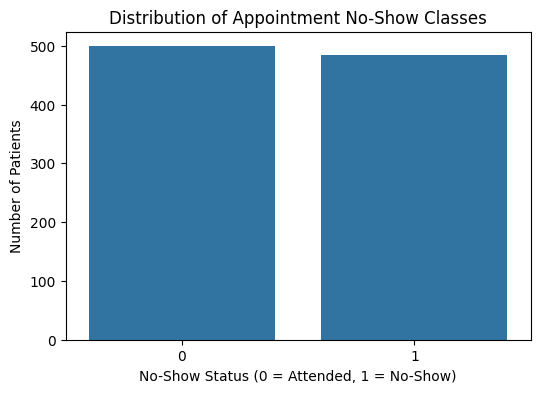

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="no_show"
)

plt.title("Distribution of Appointment No-Show Classes")
plt.xlabel("No-Show Status (0 = Attended, 1 = No-Show)")
plt.ylabel("Number of Patients")

plt.show()

#### check exact values

In [41]:
class_counts = df_clean["no_show"].value_counts()
class_percentages = df_clean["no_show"].value_counts(normalize=True) * 100

print(class_counts)
print(class_percentages)

no_show
0    499
1    485
Name: count, dtype: int64
no_show
0    50.711382
1    49.288618
Name: proportion, dtype: float64


### Class Distribution Insight

The target variable is almost perfectly balanced.

Approximately 50.71% of records belong to the attended/other class, while 49.29% belong to the no-show class.

Therefore, severe target-class imbalance is not present in the cleaned dataset.

## 3. Histogram - Age Distribution

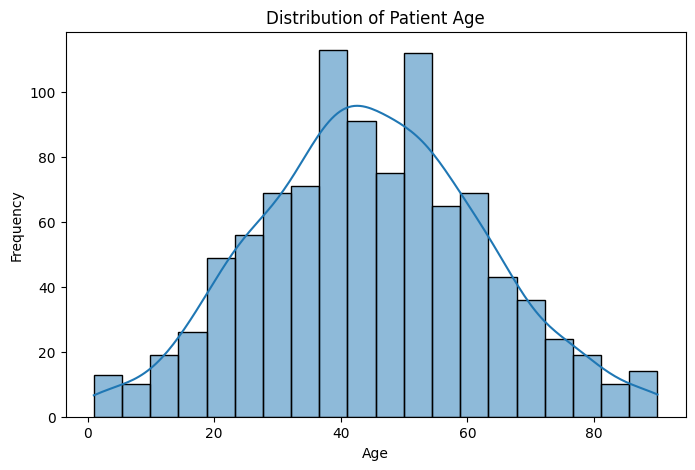

In [42]:
# visualization - Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Age Distribution Insight

Patient ages range from 1 to 90 years, with a mean of approximately 44.77 years and a median of 45 years.

The distribution covers a broad age range, indicating that the dataset represents patients from different age groups rather than being concentrated within a narrow population.

## 4. Histogram - Waiting Days

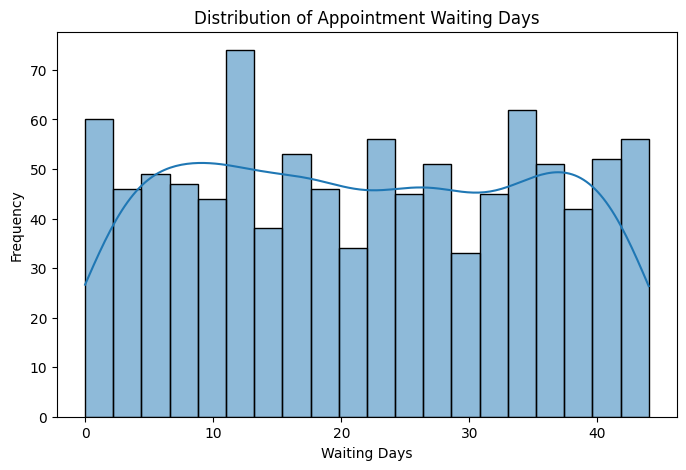

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="waiting_days",
    bins=20,
    kde=True
)

plt.title("Distribution of Appointment Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")

plt.show()

### Waiting Days Distribution

Appointment waiting time ranges from 0 to 44 days.

The mean waiting period is approximately 21.8 days, while the median is 22 days.

Because waiting time may influence the likelihood that a patient forgets or decides not to attend an appointment, this variable is especially relevant for no-show prediction.

## 5. Boxplot - Waiting Days vs No-Show

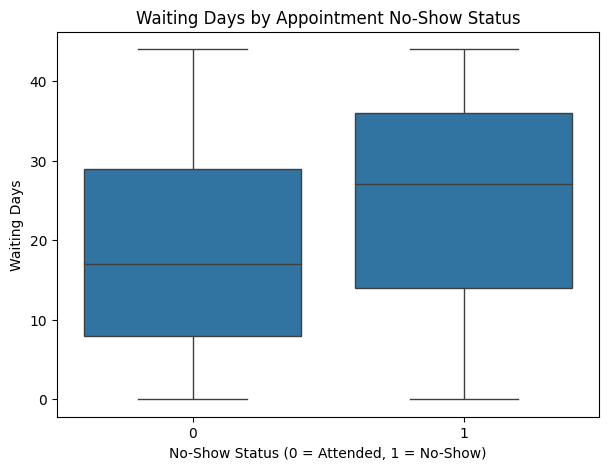

In [44]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="no_show",
    y="waiting_days"
)

plt.title("Waiting Days by Appointment No-Show Status")
plt.xlabel("No-Show Status (0 = Attended, 1 = No-Show)")
plt.ylabel("Waiting Days")

plt.show()

#### Now Calculate Means

In [45]:
df_clean.groupby("no_show")["waiting_days"].mean()

no_show
0    18.673347
1    25.006186
Name: waiting_days, dtype: float64

### Waiting Time Insight

Patients who eventually became no-shows had a noticeably longer average waiting period.

Patients in class 0 waited approximately 18.67 days on average, while patients in the no-show class waited approximately 25.01 days.

This indicates that longer appointment waiting periods may be associated with a higher probability of appointment non-attendance.

## 6. Boxplot - Previous No-Show Rate

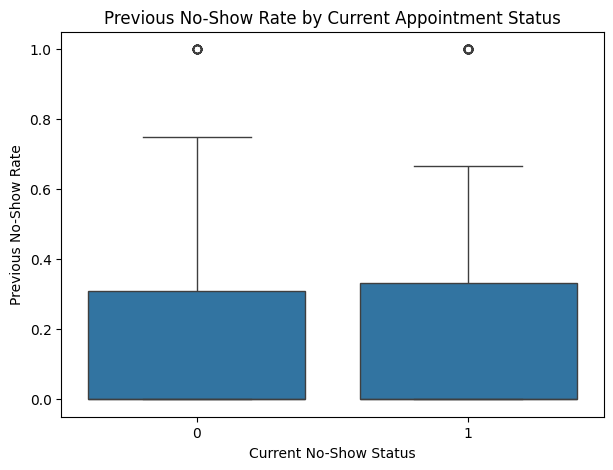

In [46]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="no_show",
    y="previous_no_show_rate"
)

plt.title("Previous No-Show Rate by Current Appointment Status")
plt.xlabel("Current No-Show Status")
plt.ylabel("Previous No-Show Rate")

plt.show()

#### Calculate Averages

In [47]:
df_clean.groupby("no_show")[
    "previous_no_show_rate"
].mean()

no_show
0    0.155163
1    0.213829
Name: previous_no_show_rate, dtype: float64

Patients who missed their current appointment had a higher average previous no-show rate than those who attended.

This suggests that historical appointment behaviour may contain useful predictive information.

## 7. Scatterplot

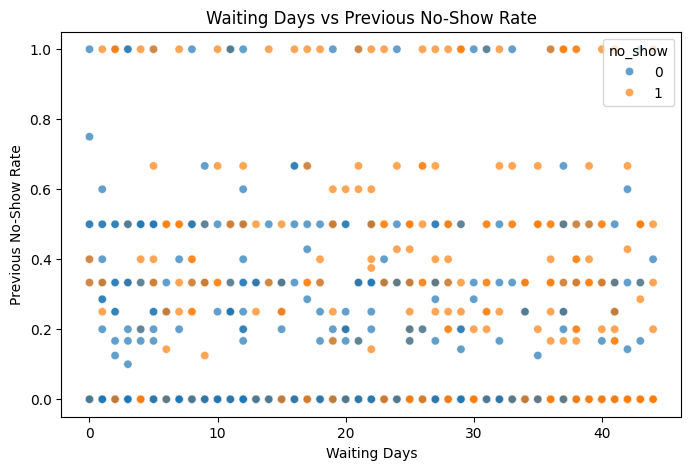

In [48]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="waiting_days",
    y="previous_no_show_rate",
    hue="no_show",
    alpha=0.7
)

plt.title("Waiting Days vs Previous No-Show Rate")
plt.xlabel("Waiting Days")
plt.ylabel("Previous No-Show Rate")

plt.show()

### Scatterplot Insight

The scatterplot compares appointment waiting time and previous no-show behaviour.

Although the two classes overlap considerably, no-show observations appear more frequently among patients with longer waiting periods and, in some cases, higher previous no-show rates.

This indicates that a combination of appointment timing and historical behaviour may provide more predictive information than either feature considered alone.

## 8. Correlation Analysis

#### Create the correlation matrix

In [49]:
correlation_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "appointment_is_weekend",
    "previous_no_show_rate",
    "has_previous_no_show",
    "no_show"
]

correlation_matrix = df_clean[
    correlation_features
].corr()

correlation_matrix

,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,appointment_is_weekend,previous_no_show_rate,has_previous_no_show,no_show
age,1.000000,-0.034763,0.007692,-0.055773,-0.080721,-0.033482,-0.067189,-0.056973,-0.061924
waiting_days,-0.034763,1.000000,0.041249,-0.028815,-0.023307,0.004199,-0.020218,-0.028137,0.242918
previous_appointments,0.007692,0.041249,1.000000,0.401425,-0.014457,0.012565,0.013780,0.333495,-0.077484
missed_previous_appointments,-0.055773,-0.028815,0.401425,1.000000,0.017013,-0.040211,0.788487,0.875793,0.085630
previous_admissions,-0.080721,-0.023307,-0.014457,0.017013,1.000000,-0.004748,0.029587,0.004681,-0.013770
appointment_is_weekend,-0.033482,0.004199,0.012565,-0.040211,-0.004748,1.000000,-0.077201,-0.032591,0.015716
previous_no_show_rate,-0.067189,-0.020218,0.013780,0.788487,0.029587,-0.077201,1.000000,0.810824,0.108277
has_previous_no_show,-0.056973,-0.028137,0.333495,0.875793,0.004681,-0.032591,0.810824,1.000000,0.077990
no_show,-0.061924,0.242918,-0.077484,0.085630,-0.013770,0.015716,0.108277,0.077990,1.000000


#### Correlation with no_show


In [50]:
correlation_matrix["no_show"].sort_values(
    ascending=False
)

no_show                         1.000000
waiting_days                    0.242918
previous_no_show_rate           0.108277
missed_previous_appointments    0.085630
has_previous_no_show            0.077990
appointment_is_weekend          0.015716
previous_admissions            -0.013770
age                            -0.061924
previous_appointments          -0.077484
Name: no_show, dtype: float64

## 9. Correlation Heatmap

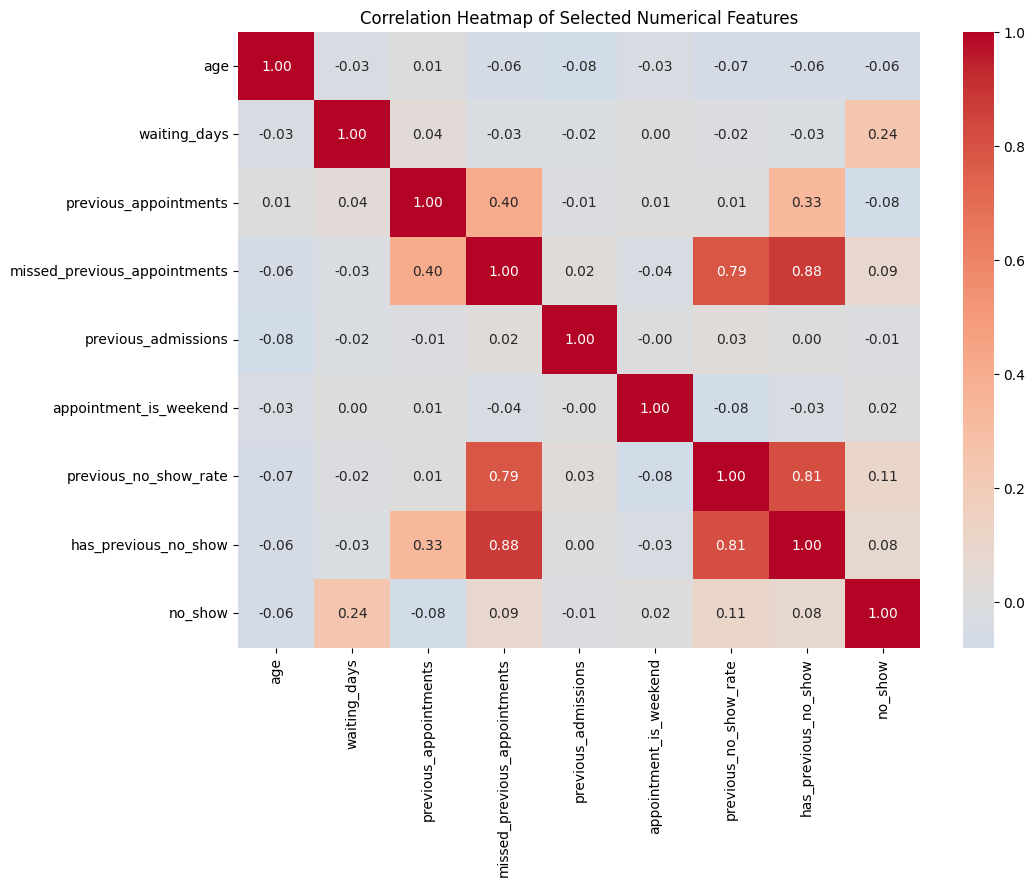

In [51]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Numerical Features")

plt.show()

### Correlation Analysis

Among the selected numerical variables, waiting days showed the strongest positive correlation with appointment no-show status, with a correlation coefficient of approximately 0.243.

Previous no-show rate, missed previous appointments, and having a previous no-show also showed smaller positive relationships with the target.

The relationships are not extremely strong, which suggests that appointment no-show behaviour is unlikely to depend on one variable alone. Machine-learning models may therefore benefit from combining several features.

## 10. Pattern Discovery - Waiting Time Groups

#### Create Groups

In [52]:
df_clean["waiting_days_group"] = pd.cut(
    df_clean["waiting_days"],
    bins=[-1, 7, 14, 21, 30, 44],
    labels=[
        "0-7",
        "8-14",
        "15-21",
        "22-30",
        "31-44"
    ]
)

#### Calaculate no-Show rates

In [53]:
waiting_pattern = (
    df_clean
    .groupby("waiting_days_group", observed=True)["no_show"]
    .agg(["count", "mean"])
)

waiting_pattern["no_show_percentage"] = (
    waiting_pattern["mean"] * 100
)

waiting_pattern

,count,mean,no_show_percentage
waiting_days_group,,,
0-7,180,0.327778,32.777778
8-14,158,0.398734,39.873418
15-21,153,0.437908,43.790850
22-30,185,0.529730,52.972973
31-44,308,0.642857,64.285714


#### Plot It

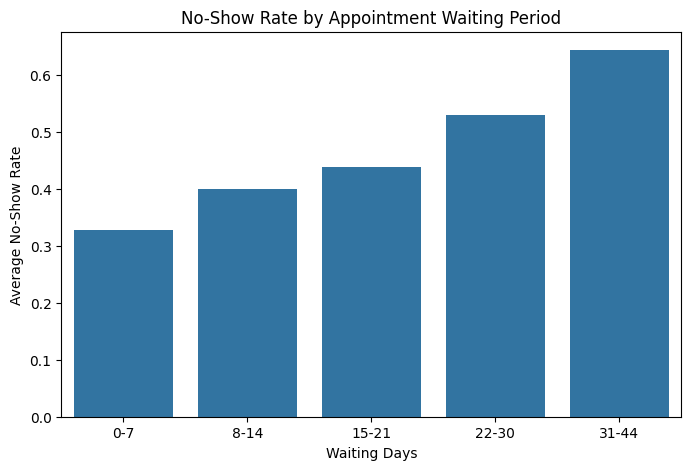

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="waiting_days_group",
    y="no_show",
    errorbar=None
)

plt.title("No-Show Rate by Appointment Waiting Period")
plt.xlabel("Waiting Days")
plt.ylabel("Average No-Show Rate")

plt.show()

### Waiting-Time Pattern

A clear increasing pattern was observed between appointment waiting time and non-attendance.

The no-show rate was approximately 32.8% among appointments scheduled within 0–7 days.

This increased progressively to approximately 64.3% among appointments with waiting periods between 31 and 44 days.

This suggests that appointment lead time may be an important predictor in the SmartCare dataset.

## 11. Pattern Discovery - Previous No-Show History

In [55]:
previous_history_pattern = (
    df_clean
    .groupby("has_previous_no_show")["no_show"]
    .agg(["count", "mean"])
)

previous_history_pattern["percentage"] = (
    previous_history_pattern["mean"] * 100
)

previous_history_pattern

,count,mean,percentage
has_previous_no_show,,,
0,578,0.460208,46.020761
1,406,0.539409,53.940887


#### Plot

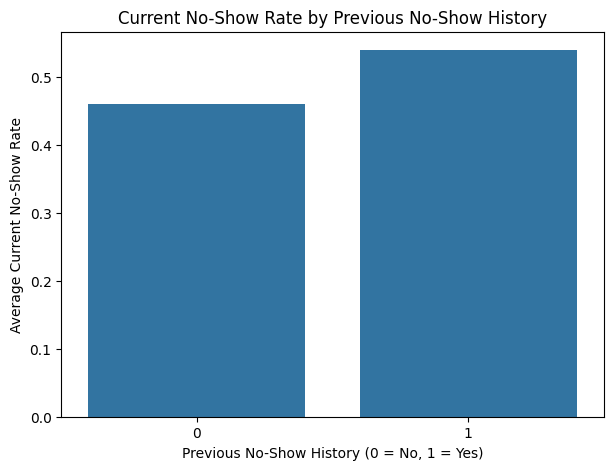

In [56]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="has_previous_no_show",
    y="no_show",
    errorbar=None
)

plt.title("Current No-Show Rate by Previous No-Show History")
plt.xlabel("Previous No-Show History (0 = No, 1 = Yes)")
plt.ylabel("Average Current No-Show Rate")

plt.show()

Patients who had previously missed at least one appointment had a current no-show rate of approximately 53.9%.

Patients without previous missed appointments had a lower rate of approximately 46.0%.

Therefore, previous non-attendance history appears to provide useful predictive information.

## 12. Department Pattern

In [57]:
department_no_show = (
    df_clean
    .groupby("department")["no_show"]
    .mean()
    .sort_values(ascending=False)
)

department_no_show

department
Neurology              0.547945
Cardiology             0.532051
General Medicine       0.487342
Pediatrics             0.485294
Radiology              0.485075
Laboratory Services    0.482456
Orthopedics            0.421429
Name: no_show, dtype: float64

#### Plot

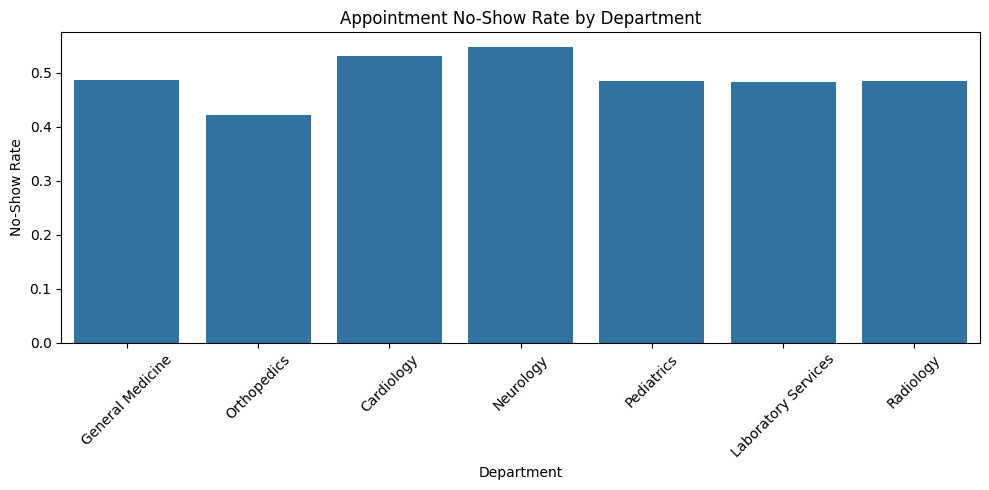

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_clean,
    x="department",
    y="no_show",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Appointment No-Show Rate by Department")
plt.xlabel("Department")
plt.ylabel("No-Show Rate")

plt.tight_layout()
plt.show()

No-show proportions differ across hospital departments.

Neurology and Cardiology recorded relatively higher no-show proportions, while Orthopedics showed a lower rate in this dataset.

However, these differences should not automatically be interpreted as causal because other patient and scheduling characteristics may contribute to the observed patterns.

## 13. Day-of - Week Pattern

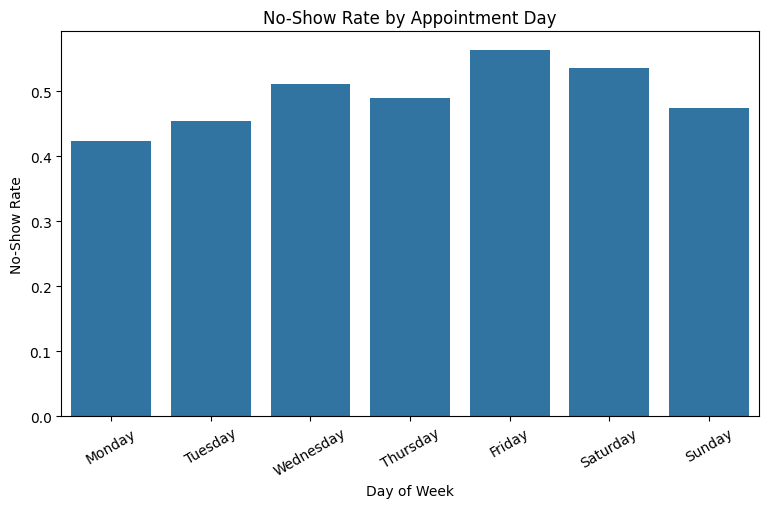

In [59]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="appointment_day_of_week",
    y="no_show",
    order=day_order,
    errorbar=None
)

plt.title("No-Show Rate by Appointment Day")
plt.xlabel("Day of Week")
plt.ylabel("No-Show Rate")

plt.xticks(rotation=30)

plt.show()

# Task 05 - Machine Learning Model Development

Three classification algorithms are developed and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are trained to predict the binary target variable `no_show`

## 1. Import the required libraries

In [60]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

import pandas as pd

## 2. pipelines use For

### Model Training Strategy

A Scikit-Learn Pipeline is used to combine preprocessing and model
training.

This ensures that preprocessing transformations are learned only
from the training data during cross-validation, helping to prevent
data leakage.

Five-fold stratified cross-validation is used to compare model
performance while preserving the class distribution in each fold.

## 3. Create the three models

In [61]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

#### Now create the pipelines

In [62]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

## 4. Define cross-validation

In [63]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 5. Define evaluation measures for model development

In [64]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 6. Baseline Logistic Regression

In [65]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression")

print(
    "Mean Accuracy:",
    logistic_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    logistic_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    logistic_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    logistic_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    logistic_cv["test_roc_auc"].mean()
)

Logistic Regression
Mean Accuracy: 0.5667661049746029
Mean Precision: 0.5613307934721661
Mean Recall: 0.5723609723609723
Mean F1: 0.5659940540888397
Mean ROC-AUC: 0.5916622934027999


## 7. Baseline Decision Tree

In [66]:
decision_tree_cv = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree")

print(
    "Mean Accuracy:",
    decision_tree_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    decision_tree_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    decision_tree_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    decision_tree_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    decision_tree_cv["test_roc_auc"].mean()
)

Decision Tree
Mean Accuracy: 0.5108199629121988
Mean Precision: 0.5038688219411112
Mean Recall: 0.5284382284382284
Mean F1: 0.5152625142093833
Mean ROC-AUC: 0.511070380041899


## 8. Baseline Random Forest

In [67]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest")

print(
    "Mean Accuracy:",
    random_forest_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    random_forest_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    random_forest_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    random_forest_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    random_forest_cv["test_roc_auc"].mean()
)

Random Forest
Mean Accuracy: 0.5641538337498992
Mean Precision: 0.5611147381369309
Mean Recall: 0.5361638361638362
Mean F1: 0.5482071954118484
Mean ROC-AUC: 0.5795300532800531


## 9. Create baseline comparison table

In [68]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_cv["test_accuracy"].mean(),
        decision_tree_cv["test_accuracy"].mean(),
        random_forest_cv["test_accuracy"].mean()
    ],

    "Precision": [
        logistic_cv["test_precision"].mean(),
        decision_tree_cv["test_precision"].mean(),
        random_forest_cv["test_precision"].mean()
    ],

    "Recall": [
        logistic_cv["test_recall"].mean(),
        decision_tree_cv["test_recall"].mean(),
        random_forest_cv["test_recall"].mean()
    ],

    "F1 Score": [
        logistic_cv["test_f1"].mean(),
        decision_tree_cv["test_f1"].mean(),
        random_forest_cv["test_f1"].mean()
    ],

    "ROC-AUC": [
        logistic_cv["test_roc_auc"].mean(),
        decision_tree_cv["test_roc_auc"].mean(),
        random_forest_cv["test_roc_auc"].mean()
    ]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5668,0.5613,0.5724,0.5660,0.5917
1,Decision Tree,0.5108,0.5039,0.5284,0.5153,0.5111
2,Random Forest,0.5642,0.5611,0.5362,0.5482,0.5795


## 10. Hyperparameter Tuning

### We use 
GridSearchCV

### We'll optimize
F1 Score

### F1 use for 
becaus over positive class is  No-Show = 1

### F1 Considers both
Precision + Recall


## 11. Tune Logistic Regression

In [69]:
logistic_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}

#### Grid Search

In [70]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logistic_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    logistic_grid.best_params_
)

print(
    "Best CV F1:",
    logistic_grid.best_score_
)

Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV F1: 0.5730120582671792


## 12. Tune Decision Tree

In [71]:
decision_tree_param_grid = {
    "model__criterion": [
        "gini",
        "entropy"
    ],

    "model__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [72]:
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

decision_tree_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    decision_tree_grid.best_params_
)

print(
    "Best CV F1:",
    decision_tree_grid.best_score_
)

Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV F1: 0.5629237453668855


## 13. Tune Random Forest

In [73]:
random_forest_param_grid = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        5,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}

In [74]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

random_forest_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    random_forest_grid.best_params_
)

print(
    "Best CV F1:",
    random_forest_grid.best_score_
)

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.5646939872258343


## 14. Compare the tuned models

In [75]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Best CV F1": [
        logistic_grid.best_score_,
        decision_tree_grid.best_score_,
        random_forest_grid.best_score_
    ]
})

tuned_results = tuned_results.sort_values(
    by="Best CV F1",
    ascending=False
)

tuned_results.round(4)

,Model,Best CV F1
0,Logistic Regression,0.5730
2,Random Forest,0.5647
1,Decision Tree,0.5629


## 15. Store the best tuned models

#### Save them in to Variable

In [76]:
best_logistic_model = (
    logistic_grid.best_estimator_
)

best_decision_tree_model = (
    decision_tree_grid.best_estimator_
)

best_random_forest_model = (
    random_forest_grid.best_estimator_
)

In [77]:
# Check
print(best_logistic_model)

print(best_decision_tree_model)

print(best_random_forest_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'waiting_days',
                                                   'previous_appointments',
                                                   'missed_previous_appointments',
                                                   'previous_admissions',
                                                   'appointment_is_weekend',
                                                   'previous_no_show_rate',
                                                   'has_previous_no_show']),
                            

# Task 06 - Model Evaluation



The tuned Logistic Regression, Decision Tree, and Random Forest models
are evaluated using the untouched test dataset.

The following binary classification metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## 1. Import evaluation libraries

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Evaluate all three models

In [79]:
models = {
    "Logistic Regression": best_logistic_model,
    "Decision Tree": best_decision_tree_model,
    "Random Forest": best_random_forest_model
}

evaluation_results = []

for model_name, model in models.items():

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability of class 1 = No-Show
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(evaluation_results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6650,0.6632,0.6495,0.6562,0.7143
1,Decision Tree,0.6193,0.6170,0.5979,0.6073,0.6225
2,Random Forest,0.6396,0.6383,0.6186,0.6283,0.6610


## 3. Confusion matrices

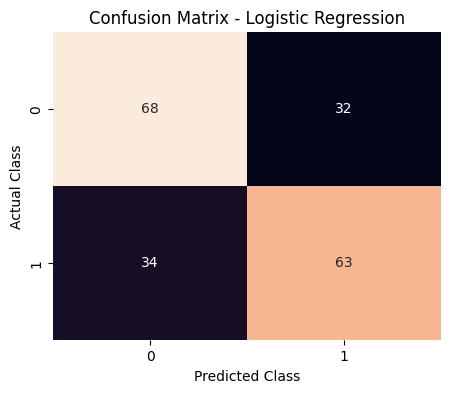

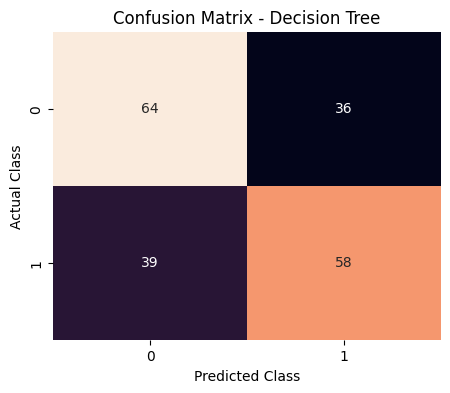

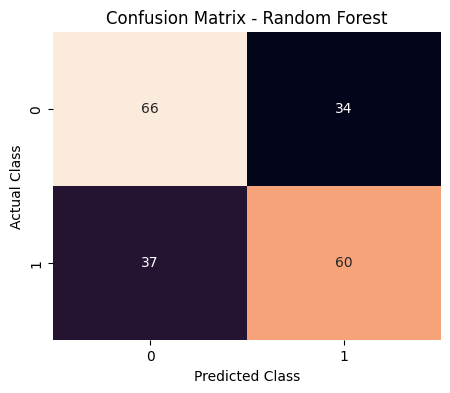

In [80]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

## 4. Classification reports

In [81]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    print("_" * 60)
    print(model_name)
    print("_" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Attended",
                "No-Show"
            ]
        )
    )

____________________________________________________________
Logistic Regression
____________________________________________________________
              precision    recall  f1-score   support

    Attended       0.67      0.68      0.67       100
     No-Show       0.66      0.65      0.66        97

    accuracy                           0.66       197
   macro avg       0.66      0.66      0.66       197
weighted avg       0.66      0.66      0.66       197

____________________________________________________________
Decision Tree
____________________________________________________________
              precision    recall  f1-score   support

    Attended       0.62      0.64      0.63       100
     No-Show       0.62      0.60      0.61        97

    accuracy                           0.62       197
   macro avg       0.62      0.62      0.62       197
weighted avg       0.62      0.62      0.62       197

____________________________________________________________
Random 

## 5. ROC Curves

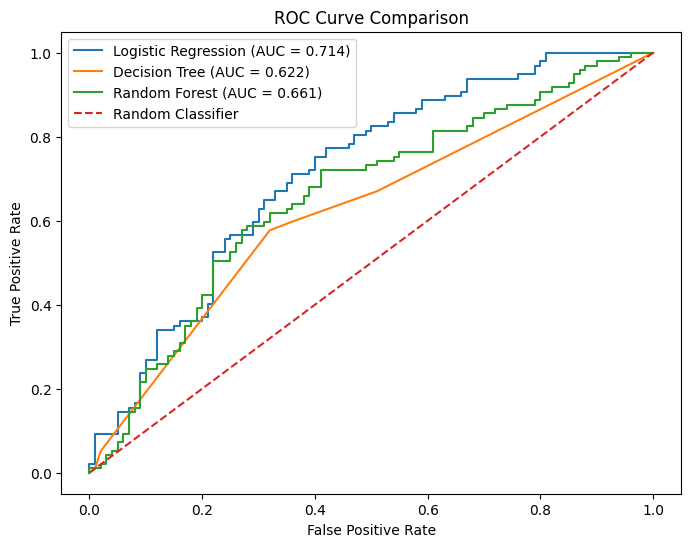

In [82]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## 6. Final model comparison chart

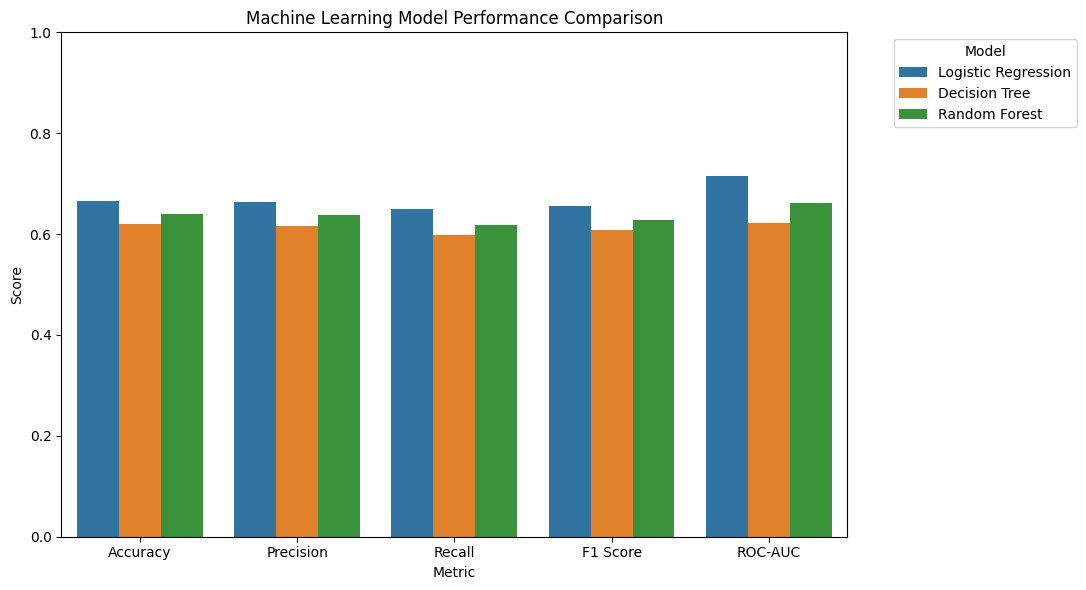

In [83]:
results_long = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## 7. Save the final model

#### Create a model Folder

In [84]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [85]:
import joblib

joblib.dump(
    best_logistic_model,
    "models/smartcare_no_show_model.joblib"
)

print("Best model saved successfully.")

Best model saved successfully.


# **Task 07 - Explainable AI Analysis**



Feature Importance Analysis is used to interpret the selected
Logistic Regression model.

The analysis focuses on:

- Important predictive features
- Direction of feature influence
- Individual prediction reasoning
- Model transparency
- Ethical implications

## 1. Import libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance

## 2. Get Logistic Regression coefficients

In [87]:
# model is inside a Pipeline so first have to extract
fitted_preprocessor = (
    best_logistic_model
    .named_steps["preprocessor"]
)

logistic_classifier = (
    best_logistic_model
    .named_steps["model"]
)

In [88]:
# Get the encoded feature names
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = (
    logistic_classifier
    .coef_[0]
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance_df["Absolute Importance"] = (
    feature_importance_df["Coefficient"].abs()
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Absolute Importance",
        ascending=False
    )
)

feature_importance_df.head(20)

,Feature,Coefficient,Absolute Importance
1,num__waiting_days,0.299849,0.299849
2,num__previous_appointments,-0.156660,0.156660
6,num__previous_no_show_rate,0.085683,0.085683
3,num__missed_previous_appointments,0.069343,0.069343
0,num__age,-0.068576,0.068576
27,cat__diagnosis_Chest Pain,0.067506,0.067506
48,cat__appointment_day_of_week_Monday,-0.064448,0.064448
21,cat__department_Neurology,0.061007,0.061007
47,cat__appointment_day_of_week_Friday,0.044232,0.044232
14,cat__blood_group_B+,0.042310,0.042310


## 3. Plot global coefficient importance

#### Tack the top 15

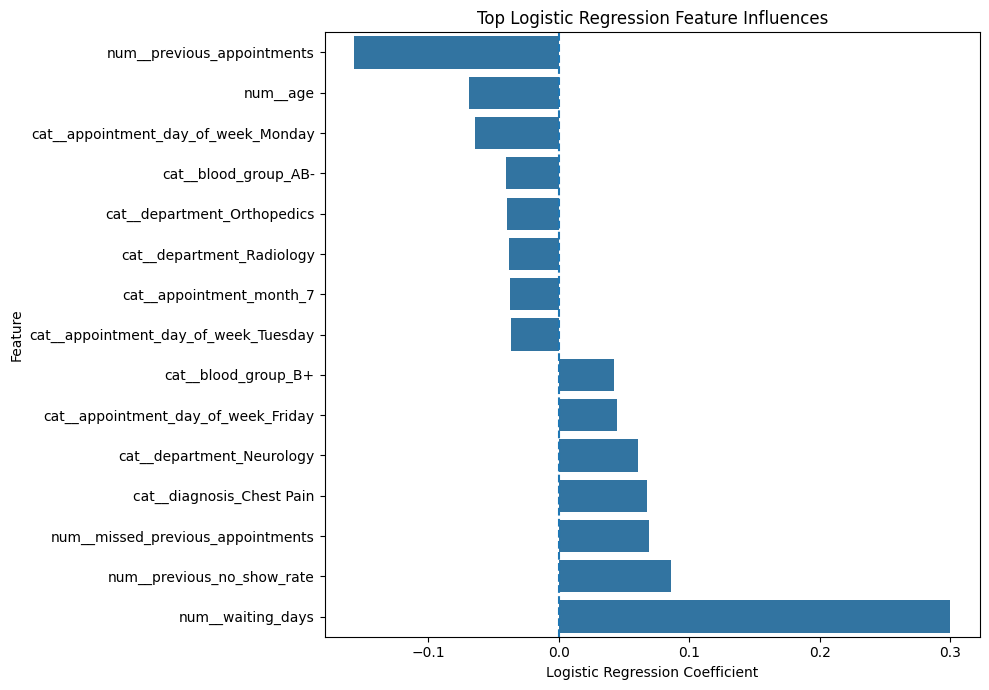

In [89]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by="Coefficient"
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Top Logistic Regression Feature Influences"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

### Coefficient Interpretation

Positive coefficients push predictions toward the No-Show class
(class 1), while negative coefficients push predictions toward the
Attended class (class 0).

The magnitude of the coefficient indicates the strength of the
feature's contribution within the fitted Logistic Regression model.

Waiting days showed the strongest positive influence on no-show
prediction.

Previous no-show behaviour also showed positive influence, supporting
the findings obtained during Exploratory Data Analysis.

## 4. Use Permutation Feature Importance

In [90]:
permutation_result = permutation_importance(
    best_logistic_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

#### Create the table 

In [91]:
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

permutation_df

,Feature,Importance,Std
5,waiting_days,0.160639,0.020752
7,missed_previous_appointments,0.018722,0.006282
12,previous_no_show_rate,0.010469,0.007514
6,previous_appointments,0.003469,0.015092
13,has_previous_no_show,0.003454,0.001524
10,appointment_day_of_week,0.002990,0.003621
9,appointment_month,0.002851,0.003613
4,diagnosis,0.002098,0.002137
11,appointment_is_weekend,0.000871,0.000855
3,department,0.000381,0.004673


## 5. Plot permutation importance

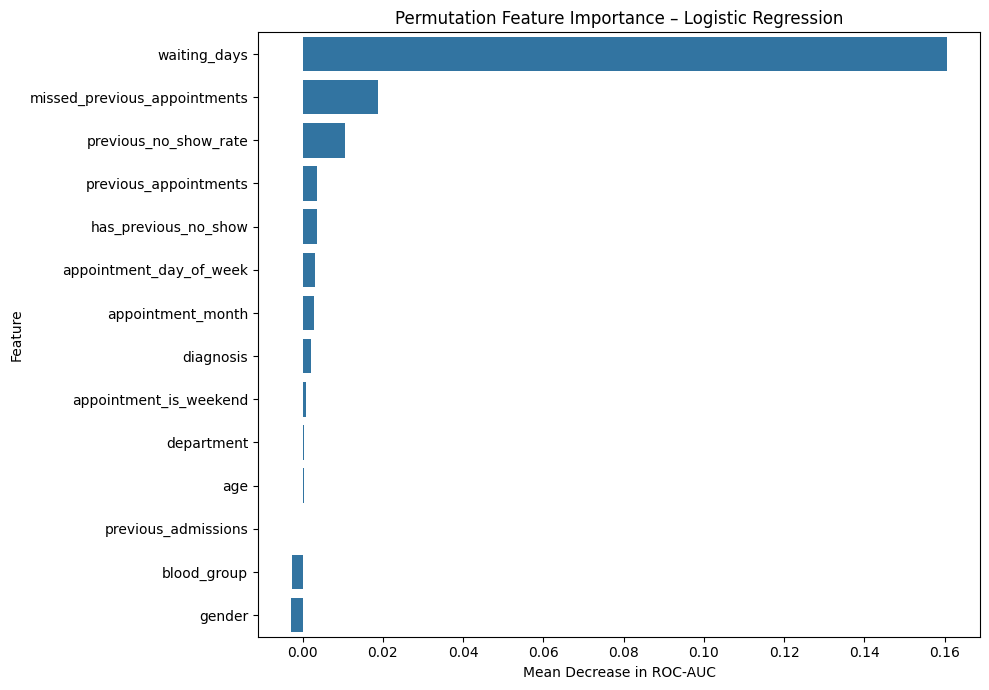

In [92]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=permutation_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Permutation Feature Importance – Logistic Regression"
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

### Permutation Importance Interpretation

Permutation importance showed that **waiting_days** was substantially
more influential than the other selected variables.

When the values of waiting days were randomly disturbed, the model's
ROC-AUC decreased more strongly than when other features were
permuted.

This indicates that the Logistic Regression model relies heavily on
appointment waiting time when distinguishing between attended and
no-show appointments.

Historical appointment behaviour, including missed previous
appointments and previous no-show rate, also contributed to the
prediction process.

## 6. Explain one individual prediction

In [93]:
# We can automatically select a test patient with a high predicted no-show probability
test_probabilities = (
    best_logistic_model
    .predict_proba(X_test)[:, 1]
)

highest_risk_position = np.argmax(
    test_probabilities
)

sample_index = (
    X_test.index[
        highest_risk_position
    ]
)

sample_patient = (
    X_test.loc[[sample_index]]
)

sample_patient

,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,appointment_month,appointment_day_of_week,appointment_is_weekend,previous_no_show_rate,has_previous_no_show
890,32,Male,AB-,Orthopedics,Asthma,37,1,1,0,4,Wednesday,0,1.0,1


In [94]:
#### Get Prediction
sample_prediction = (
    best_logistic_model
    .predict(sample_patient)[0]
)

sample_probability = (
    best_logistic_model
    .predict_proba(sample_patient)[0, 1]
)

print(
    "Predicted Class:",
    sample_prediction
)

print(
    "No-Show Probability:",
    round(sample_probability, 4)
)

Predicted Class: 1
No-Show Probability: 0.701


## 7. Calculate contributions for that patient

In [95]:
sample_processed = (
    fitted_preprocessor
    .transform(sample_patient)
)

if hasattr(
    sample_processed,
    "toarray"
):
    sample_processed = (
        sample_processed
        .toarray()
    )

sample_values = (
    sample_processed[0]
)

sample_contributions = (
    sample_values
    * logistic_classifier.coef_[0]
)

local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": sample_contributions
})

local_explanation[
    "Absolute Contribution"
] = (
    local_explanation[
        "Contribution"
    ].abs()
)

local_explanation = (
    local_explanation
    .sort_values(
        by="Absolute Contribution",
        ascending=False
    )
)

local_explanation.head(10)

,Feature,Contribution,Absolute Contribution
1,num__waiting_days,0.347182,0.347182
6,num__previous_no_show_rate,0.252712,0.252712
2,num__previous_appointments,0.179969,0.179969
0,num__age,0.049888,0.049888
3,num__missed_previous_appointments,0.041209,0.041209
13,cat__blood_group_AB-,-0.040483,0.040483
22,cat__department_Orthopedics,-0.039605,0.039605
25,cat__diagnosis_Asthma,0.035453,0.035453
53,cat__appointment_day_of_week_Wednesday,0.033682,0.033682
41,cat__appointment_month_4,-0.026555,0.026555


## 8. Plot individual prediction explanation

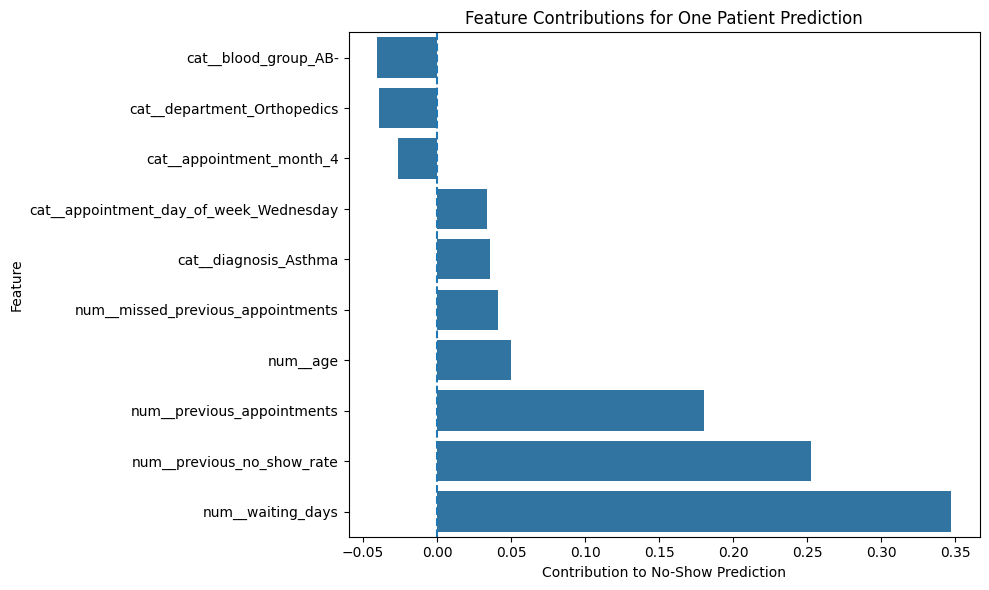

In [96]:
top_local = (
    local_explanation
    .head(10)
    .sort_values(
        by="Contribution"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_local,
    x="Contribution",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Feature Contributions for One Patient Prediction"
)

plt.xlabel(
    "Contribution to No-Show Prediction"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

## 9. Transparency



The selected Logistic Regression model provides better interpretability
than many complex black-box algorithms because the direction and
relative influence of model coefficients can be examined.

Global feature importance allows hospital staff to understand the
factors used by the model overall.

Individual contribution analysis can also be used to investigate why a
specific appointment received a particular prediction.

This improves transparency and allows users to examine the model rather
than relying only on an unexplained prediction.

## 10. Ethical implications

Although the prediction model may support hospital appointment
management, its results should not be treated as unquestionable
decisions

A patient predicted as a high no-show risk may still attend the
appointment. Therefore, the model should be used as a decision-support
tool rather than a system for denying or cancelling appointments

Demographic variables such as age and gender must also be treated
carefully because inappropriate use could introduce or reinforce unfair
treatment of particular patient groups

False-positive predictions may result in patients being unnecessarily
labelled as high-risk, while false-negative predictions may cause the
hospital to miss opportunities for useful interventions

Patient information should be stored securely and accessed only for
appropriate healthcare purposes because the dataset contains sensitive
health-related information

Model performance and fairness should also be monitored over time
because patient behaviour and hospital processes may change

## 11. Task 07 conclusion

Feature Importance Analysis was used to explain the selected Logistic
Regression model.

Both coefficient analysis and permutation importance identified
`waiting_days` as the strongest predictive feature.

Previous appointment behaviour, including missed previous appointments
and previous no-show rate, also contributed to no-show prediction.

Individual contribution analysis demonstrated how the model can provide
reasoning for a specific patient's prediction.

The analysis improves model transparency; however, predictions should
be used to support human decision-making rather than automatically
penalizing or denying services to patients.